In [1]:
import requests
from IPython.core.display import HTML
HTML(f"""
<style>
</style>
""")

# Question 2 b)
Focus on how linear and non-linear models can be learned using matrix inverses. Discuss the relationship between model complexity (e.g., polynomial degree) and the amount of data needed to accurately train these models with matrix inverses.

- Linear models -> Use linear equations
- Linear equations using matrix $Ax=b$
- We need inverse $x = A^{-1}b$
- From dataset we know inputs and labels, but we need weights
- Number of unknowns = how many data points we need (also 1 higher than the degree of the model)
- More data points than needed - psuedo inverse (Linear least squares)
- Non-linear models -> If linear in parameters, same method


# Polynomial models

**Overview**
In this exercise you will implement a method to estimate the model parameters of single variate (single input) 2-nd and 3-rd order polynomials and use these models to predict a label for new datapoints. Next week you will extend this method to $n$-th order, single variate, polynomials in a fairly straightforward manner. 


**Important**
Ensure that you have finished all of the tasks from the W3 in-class exercise
, as you will need them for the following tasks. 


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#loading7">Task 1: Data preparation (data wrangling)</a>
            </li>
            <li>
            <a href="#loading8">Task 2: Constructing the design matrix</a>
            </li>
            <li>
            <a href="#loading9">Task 3: Inverting the design matrix</a>
            </li>
            <li>
            <a href="#loading10">Task 4: Plotting</a>
            </li>
            <li>
            <a href="#loading10130">Task 5: Making predictions</a>
            </li>
            <li>
            <a href="#loading12">Task 6: Load data</a>
            </li>
            <li>
            <a href="#loading11">Task 7: Third order polynomials</a>
            </li>
            <li>
            <a href="#loading13">Task 8: Plotting</a>
            </li>
            <li>
            <a href="#loading145">Task 9: Observe</a>
            </li>
            <li>
            <a href="#loading100">Task 10: Making predictions</a>
            </li>
            <li>
            <a href="#loading1030">Task 11: Observe</a>
            </li>
        </ul>
    </div>
</article>

## 2nd-order Polynomial model
A 2nd-order polynomial model, also known as a quadratic model, can be expressed as:

$$ y = w_0 + w_1 x + w_2 x^2 $$
This model assumes that the relationship between the input $x$ and the label $y$ is non-linear and quadratic. This way a "curved" relationship can be modelled which can capture patterns that a simple linear model might miss. 
By _fitting_ this model, the aim is to find (learn) the parameters $w_0$, $w_1$, and $w_2$ that minimize the difference between the predicted values and the actual data, providing a more flexible fit compared to a linear model.

---
**Task 1 (easy): Load data👩‍💻**
1. Run the cell below to load libraries and construct the datasets.


---

In [2]:
import numpy as np
import matplotlib.pyplot as plt

quadratic_dataset_1 = np.array([[1, 2], 
                                [2, 3], 
                                [3, 6]])

# quadratic_dataset_2 = np.array([[9, 3], 
#                                 [7, 5], 
#                                 [1, 9]])

# quadratic_dataset_3 = np.array([[8, 4], 
#                                 [10, 5], 
#                                 [3, 1]])

Throughout the next tasks, the aim is to construct the design matrix using the known variables, followed by learning the model parameters (solving) using the inverse of the design matrix. The subsequent tasks involve using the learnt model parameters to predict new unseen inputs and plotting the results.

---
**Task 2 (easy): Data preparation (data wrangling)👩‍💻**
1. For each dataset identify which values correspond to inputs and which are the labels.
2. Complete the `separate_inputs_labels`
 function below. The function takes a dataset as input and returns the inputs as the `X_quadratic`
 matrix and the labels as the `y_quadratic`
 vector.


---

In [3]:
def separate_inputs_labels(dataset):
    """
    This function takes a dataset as input and returns the inputs and labels.
    
    Parameters:
    dataset (numpy array): The dataset to be separated.
    
    Returns:
    X_quadratic (3x1 numpy array): The input matrix.
    y_quadratic (1x3 numpy array): The labels vector.
    """
    
    X_quadratic = np.zeros((3, 1))
    y_quadratic = np.zeros((3))

    for i in range(len(dataset)):
        X_quadratic[i, 0] = dataset[i, 0]
        y_quadratic[i] = dataset[i, 1]
        
    return X_quadratic, y_quadratic

# Applying the function to each quadratic dataset
X1_quadratic, y1_quadratic = separate_inputs_labels(quadratic_dataset_1)
# X2_quadratic, y2_quadratic = separate_inputs_labels(quadratic_dataset_2)
# X3_quadratic, y3_quadratic = separate_inputs_labels(quadratic_dataset_3)

print("X1_quadratic: \n", X1_quadratic)
print("y1_quadratic: \n", y1_quadratic)

# print("X2_quadratic: \n", X2_quadratic)
# print("y2_quadratic: \n", y2_quadratic)

# print("X3_quadratic: \n", X3_quadratic)
# print("y3_quadratic: \n", y3_quadratic)

X1_quadratic: 
 [[1.]
 [2.]
 [3.]]
y1_quadratic: 
 [2. 3. 6.]



---
**Task 3 (easy): Constructing the design matrix👩‍💻**
Reuse the code from the W3 in-class exercise
:
1. For each data set construct the design matrix by adding a 2nd order polynomial term.
2. Print the results.


---

In [4]:
def makeDesignMatrix(x_quadratic):
    X_quadratic_design = np.ones((3, 3)) # 3x3 matrix because we have three unknowns (w0, w1, w2) and we need a column of ones for the bias term (w0)

    for i in range(len(X_quadratic_design)):
        X_quadratic_design[i, 1] = x_quadratic[i, 0]
        X_quadratic_design[i, 0] = x_quadratic[i, 0]**2
    return X_quadratic_design # first column is x^2, second column is x, and third column is always 1 

X1_quadratic_design = makeDesignMatrix(X1_quadratic)
print("Design Matrix for Dataset 1:\n", X1_quadratic_design)
# X2_quadratic_design = makeDesignMatrix(X2_quadratic)
# print("Design Matrix for Dataset 2:\n", X2_quadratic_design)
# X3_quadratic_design = makeDesignMatrix(X3_quadratic)
# print("Design Matrix for Dataset 3:\n", X3_quadratic_design)

Design Matrix for Dataset 1:
 [[1. 1. 1.]
 [4. 2. 1.]
 [9. 3. 1.]]



---
**Task 4 (easy): Inverting the design matrix👩‍💻**
1. Compute the inverse of each design matrix.
2. Compute the model parameters (referenced as `weigths`
 in the cells below), then print the results.


---

In [5]:
# w = A^-1 * y
invDM1 = np.linalg.inv(X1_quadratic_design)
print(invDM1)
weights1_quadratic = invDM1 @ y1_quadratic

# invDM2 = np.linalg.inv(X2_quadratic_design)
# print(invDM2)
# weights2_quadratic = invDM2 @ y2_quadratic

# invDM3 = np.linalg.inv(X3_quadratic_design)
# print(invDM3)
# weights3_quadratic = invDM3 @ y3_quadratic

print("Model parameters for Model 1:", weights1_quadratic)
# print("Model parameters for Model 2:", weights2_quadratic)
# print("Model parameters for Model 2:", weights3_quadratic)

[[ 0.5 -1.   0.5]
 [-2.5  4.  -1.5]
 [ 3.  -3.   1. ]]
Model parameters for Model 1: [ 1. -2.  3.]



---
**Task 5 (easy): Plotting👩‍💻💡**
1. Use the `plot_quadratic_model`
 function to plot the results. 


---

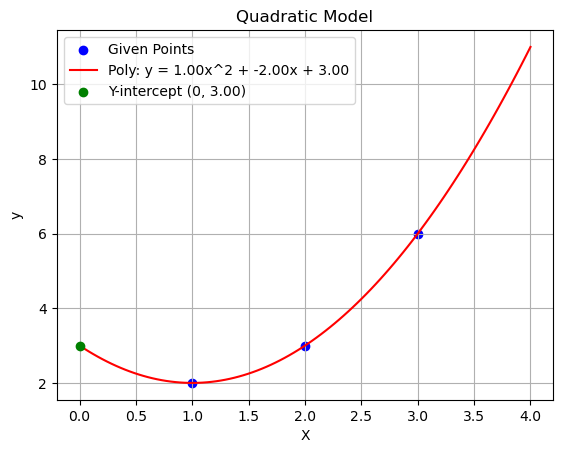

In [6]:
# Function to plot data points and fitted quadratic model
def plot_quadratic_model(X, y, weights):
    # Plot the data points
    plt.scatter(X, y, color='blue', label='Given Points')
    
    # Extend x_vals range to include zero for correct visualization
    x_vals = np.linspace(0, max(X) + 1, 100)
    y_vals = weights[0] * x_vals**2 + weights[1] * x_vals + weights[2]
    
    # Plot the fitted polynomial
    plt.plot(x_vals, 
             y_vals, 
             color='red', 
             label=f'Poly: y = {weights[0]:.2f}x^2 + {weights[1]:.2f}x + {weights[2]:.2f}')
    
    # Plot the y-intercept
    plt.scatter(0, weights[2], color='green', zorder=5, label=f'Y-intercept (0, {weights[2]:.2f})')
    
    # Add title and labels
    plt.title('Quadratic Model')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


plot_quadratic_model(X1_quadratic, y1_quadratic, weights1_quadratic)
# plot_quadratic_model(X2_quadratic, y2_quadratic, weights2_quadratic)
# plot_quadratic_model(X3_quadratic, y3_quadratic, weights3_quadratic)


---
**Task 6 (easy): Observe💡**
1. Visually inspect the plots and discuss how the model parameters influence the shape and position of the fitted curve. 
2. Compare the results of the polynomial model to the outcome of the linear model implemented in the in-class exercise.


---

## Answer:
### 1)
The model parameters influence the slope and the direction of the fitted curve. The third model parameter (w0) determines the curve's interception with the y-axis. If the first model parameter is larger than 0, the curve opens upwards; if it is less than 0, it opens downwards. The second parameter determines if the curve is left or right of the y-axis. First and second parameter have same sign (+/-), the top point of the curve is to the left of the y-axis, and if they don't have the same sign, then it is to the right of the y-axis. 

To make predictions with a polynomial model, you apply the polynomial equation to the new input using the estimated model parameters. The model then predicts the label (output) based on the learned model parameters and input values.

---
**Task 7 (easy): Making predictions👩‍💻💡**
The cell below contains an array of new inputs. Follow these steps to predict a label for the new input:
1. For each trained model, use the model parameters to predict a label for the new input. The model parameters for the different models should lead to different predictions. Store the predicted label as a separate variable. 
2. Plot the results using the `plot_quadratic_model_with_predictions`
 function. 
3. Compare the plots and the predicted labels obtained with the different models.
4. Extend the `new_inputs`
 array with the points `1.5`
 and `-1`
. Follow the same steps as above to obtain predicted labels for each input. 
5. Following the above steps should result in 3 predicted labels for each model. A total of 9 predicted values must be submitted as part of the **mandatory** activity on [Grasple](https://app.grasple.com/#/courses/10532/ci/734077/diagnoses/12887)



---

Model 1 prediction of new input '14'
170.99999999999986
Design matrix for all new inputs:
[[196.    14.     1.  ]
 [  2.25   1.5    1.  ]
 [  1.    -1.     1.  ]]
Model 1 prediction of all new inputs
[171.     2.25   6.  ]


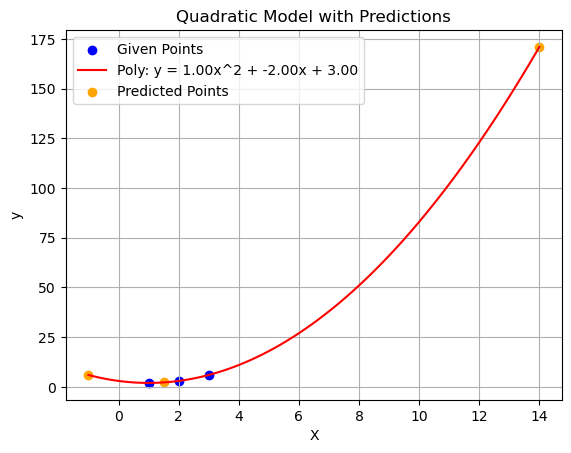

In [7]:
# New array of inputs for prediction, currently containing a single element
new_input = np.array([14])

# Predictions for the new input '14'
m1_pred = weights1_quadratic[0]*(new_input[0]**2) + weights1_quadratic[1]*new_input[0] + weights1_quadratic[2] 
print("Model 1 prediction of new input '14'")
print(m1_pred)

# m2_pred = weights2_quadratic[0]*(new_input[0]**2) + weights2_quadratic[1]*new_input[0] + weights2_quadratic[2]
# print("Model 2 prediction of new input '14'")
# print(m2_pred)

# m3_pred = weights3_quadratic[0]*(new_input[0]**2) + weights3_quadratic[1]*new_input[0] + weights3_quadratic[2]
# print("Model 3 prediction of new input '14'")
# print(m3_pred)

# Predictions for all new inputs
new_inputs = np.array([[14], [1.5], [-1]])

print("Design matrix for all new inputs:")
design_matrix_new_inputs = makeDesignMatrix(new_inputs)
print(design_matrix_new_inputs)

m1_preds = design_matrix_new_inputs@weights1_quadratic
print("Model 1 prediction of all new inputs")
print(m1_preds)

# m2_preds = design_matrix_new_inputs@weights2_quadratic
# print("Model 2 prediction of all new inputs")
# print(m2_preds)

# m3_preds = design_matrix_new_inputs@weights3_quadratic
# print("Model 3 prediction of all new inputs")
# print(m3_preds)

def plot_quadratic_model_with_predictions(X, y, weights, new_input, predicted_labels):
    # Plot the original data points
    plt.scatter(X, y, color='blue', label='Given Points')

    # Plot the fitted quadratic model
    x_vals = np.linspace(min(X.min(), new_input.min()), max(X.max(), new_input.max()), 100)
    y_vals = weights[0] * x_vals**2 + weights[1] * x_vals + weights[2]
    plt.plot(
    x_vals, 
    y_vals, 
    color='red', 
    label=(
        f'Poly: y = {weights[0]:.2f}x^2 + {weights[1]:.2f}x + '
        f'{weights[2]:.2f}'
    ))

    # Plot the new inputs and their predicted labels
    plt.scatter(new_input, predicted_labels, color='orange', label='Predicted Points')

    # Add title, labels, and legend
    plt.title('Quadratic Model with Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_quadratic_model_with_predictions(X1_quadratic, y1_quadratic, weights1_quadratic, new_inputs, m1_preds)
# plot_quadratic_model_with_predictions(X2_quadratic, y2_quadratic, weights2_quadratic, new_inputs, m2_preds)
# plot_quadratic_model_with_predictions(X3_quadratic, y3_quadratic, weights3_quadratic, new_inputs, m3_preds)

## 3rd-order Polynomial models
This exercise is about using third order polynomials to obtained increased flexibility by introducing a cubic term $x^3$.
A 3rd-order polynomial model is given by

$$ y = w_0 + w_1 x + w_2 x^2 + w_3 x^3 $$
In the next tasks you will follow similar steps as with 1. and 2. order polynomial. This includes:
1. Preparing the dataset.
2. Constructing the design matrix.
3. Calculating the model weights.
4. Plotting the results.
5. Using the model to make predictions for new inputs.


---
**Task 8 (easy): Load data👩‍💻**
1. Run the cell below to construct a new dataset.


---:


In [8]:
cubic_dataset = np.array([[7, 6], [5, 24], [8, 60], [1, 120]])
print(cubic_dataset.shape)

(4, 2)



---
**Task 9 (easy): Third order polynomials👩‍💻**
1. For each dataset identify which values correspond to inputs and which are the ground truth labels.
2. Create a $4 \times 1$ matrix called `X_cubic`
 that contain the inputs, and a vector called `y_cubic`
 containing the corresponding ground truth labels.
3. Create the design matrix, remember to add tthe higher order terms.
4. Calculate the inverse of the design matrix.
5. Follow the same procedure as previous to compute the model parameters.


---

In [9]:
# The inputs are in the first column of the dataset, and the ground truth labels are in the second column of the dataset
def separate_inputs_labels(dataset):
    """
    This function takes a dataset as input and returns the inputs and labels.
    
    Parameters:
    dataset (numpy array): The dataset to be separated.
    
    Returns:
    X_cubic (4x1 numpy array): The input matrix.
    y_cubic (1x4 numpy array): The labels vector.
    """
    
    X_cubic_input = np.zeros((4, 1))
    y_cubic_ground_truth = np.zeros((4))

    for i in range(len(dataset)):
        X_cubic_input[i, 0] = dataset[i, 0]
        y_cubic_ground_truth[i] = dataset[i, 1]
        
    return X_cubic_input, y_cubic_ground_truth

X_cubic, y_cubic = separate_inputs_labels(cubic_dataset)
print("X_cubic: \n", X_cubic)
print("y_cubic: \n", y_cubic)

def makeDesignMatrixCubic(x_cubic):
    X_cubic_design = np.ones((4, 4)) # 4x4 matrix because we have four unknowns (w0, w1, w2, w3) and we need a column of ones for the bias term (w0)

    for i in range(len(X_cubic_design)):
        X_cubic_design[i, 2] = x_cubic[i, 0]
        X_cubic_design[i, 1] = x_cubic[i, 0]**2
        X_cubic_design[i, 0] = x_cubic[i, 0]**3
    return X_cubic_design # first column is x^3, second is x^2, third column is x, and fourth column is always 1 

cubic_design_matrix = makeDesignMatrixCubic(X_cubic)
print("Cubic design matrix:")
print(cubic_design_matrix)

inverse_cubic_design = np.linalg.inv(cubic_design_matrix)
print("Inverse design matrix:")
print(inverse_cubic_design)

cubic_model_params = inverse_cubic_design@y_cubic
print("Cubic model params:")
print(cubic_model_params)

X_cubic: 
 [[7.]
 [5.]
 [8.]
 [1.]]
y_cubic: 
 [  6.  24.  60. 120.]
Cubic design matrix:
[[343.  49.   7.   1.]
 [125.  25.   5.   1.]
 [512.  64.   8.   1.]
 [  1.   1.   1.   1.]]
Inverse design matrix:
[[-0.08333333  0.04166667  0.04761905 -0.00595238]
 [ 1.16666667 -0.66666667 -0.61904762  0.11904762]
 [-4.41666667  2.95833333  2.23809524 -0.7797619 ]
 [ 3.33333333 -2.33333333 -1.66666667  1.66666667]]
Cubic model params:
[  2.64285714 -31.85714286  85.21428571  64.        ]



---
**Task 10 (easy): Plotting👩‍💻💡**
1. Use the `plot_cubic_model`
 function to plot the results.
2. Visually inspect the plots and discuss how the model parameters influence the shape and position of the fitted curve.


---

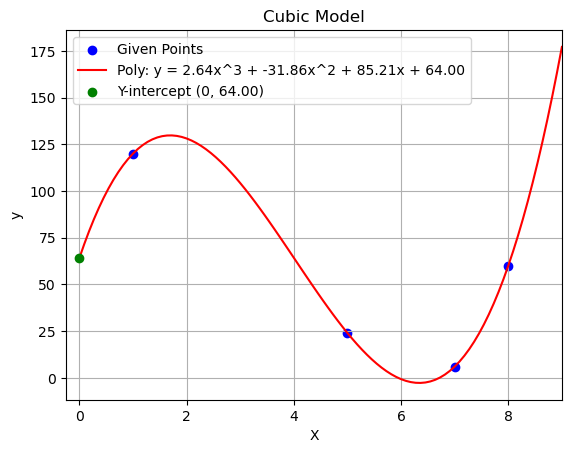

In [10]:
# Function to plot data points and fitted cubic model
def plot_cubic_model(X, y, weights):
    # Plot the data points
    plt.scatter(X, y, color='blue', label='Given Points')
    
    # Extend x_vals range to include zero for correct visualization
    x_vals = np.linspace(0, max(X) + 1, 100)
    y_vals = weights[0] * x_vals**3 + weights[1] * x_vals**2 + weights[2] * x_vals + weights[3]
    
    # Plot the fitted polynomial
    plt.plot(
    x_vals, 
    y_vals, 
    color='red', 
    label=(
        f'Poly: y = {weights[0]:.2f}x^3 + {weights[1]:.2f}x^2 + '
        f'{weights[2]:.2f}x + {weights[3]:.2f}'
    ))
    
    # Plot the y-intercept
    plt.scatter(0, weights[3], color='green', zorder=5, label=f'Y-intercept (0, {weights[3]:.2f})')
    
    # Add title and labels
    plt.title('Cubic Model')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.xlim([-0.25, max(X) + 1])  # Ensure the x-axis starts from 0
    plt.show()

plot_cubic_model(X_cubic, y_cubic, cubic_model_params)

## Answer: 
### 2)
If first parameter is positive the graph rises to the right, if negative it falls to the right. Second parameter influences horizontal position and symmetry, shifting the graph left or right. The third parameter affects the slope at the interception point and the shape of the curve (Here it is positive meaning that the slope is increasing in the interception with the y-axis). The last parameter is the interception with the y-axis. 


---
**Task 11 (easy): Observe💡**
1. Compare the results of the 3rd order polynomial to the 1st and 2nd order models. Based on the plots, which model shows the best fit?


---

## Answer: 
### 1)

We can see from the positions of the data points that if we had use a 1st order model, we wouldn't be able to fit a straight line through all the data points. We would have the same problem if we used a 2nd order model. 


---
**Task 12 (easy): Making predictions👩‍💻💡**
In this task, the learned 3rd order polynomial model is used to predict labels for the `new_inputs`
 array defined below.
1. Use the obtained cubic model parameters to predict labels for the new inputs. 
2. Plot the results using the `plot_cubic_model_with_predictions`
 function.


---

Design matrix new inputs:
[[ 2.744e+03  1.960e+02  1.400e+01  1.000e+00]
 [ 3.375e+00  2.250e+00  1.500e+00  1.000e+00]
 [-1.000e+00  1.000e+00 -1.000e+00  1.000e+00]]
Cubic model prediction of all new inputs
[2265.          129.0625      -55.71428571]


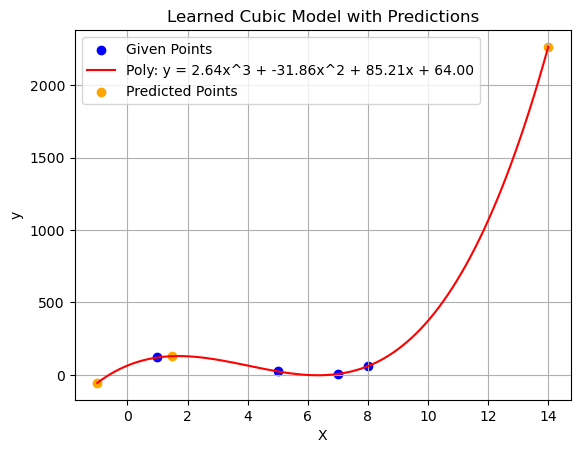

In [11]:
new_inputs = np.array([14, 1.5, -1])

design_matrix_new_inputs = np.vander(new_inputs, 4) # creates a design matrix with increasing orders/powers of the input values
print("Design matrix new inputs:")
print(design_matrix_new_inputs)

cubic_predictions = design_matrix_new_inputs@cubic_model_params
print("Cubic model prediction of all new inputs")
print(cubic_predictions)


# Function to plot data points, fitted cubic model, and predictions
def plot_cubic_model_with_predictions(X, y, weights, new_inputs, predicted_labels):
    # Plot the original data points
    plt.scatter(X, y, color='blue', label='Given Points')

    # Plot the fitted cubic model
    x_vals = np.linspace(min(min(X), min(new_inputs)), max(max(X), max(new_inputs)), 100)
    y_vals = weights[0] * x_vals**3 + weights[1] * x_vals**2 + weights[2] * x_vals + weights[3]
    plt.plot(
    x_vals, 
    y_vals, 
    color='red', 
    label=(
        f'Poly: y = {weights[0]:.2f}x^3 + {weights[1]:.2f}x^2 + '
        f'{weights[2]:.2f}x + {weights[3]:.2f}'
    ))

    # Plot the new inputs and their predicted labels
    plt.scatter(new_inputs, predicted_labels, color='orange', label='Predicted Points')

    # Add title, labels, and legend
    plt.title('Learned Cubic Model with Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_cubic_model_with_predictions(X_cubic, y_cubic, cubic_model_params, new_inputs, cubic_predictions)


---
**Task 13 (easy): Observe💡**
1. Compare the predictions of the cubic model with the predicitons of the quadratic models.
2. Which model is prefered in terms of representing the relationship between inputs and outputs and why?


---

## Answer:
### 1) 
Even though we are using the same input data points, we get very different predictions depending on which model we use to predict the labels. Since we now are using a 3rd order polynomial, the predicted labels will fit the curve of the polynomial, and those labels can therefore not be compared to the labels we got from the second order polynomial predictions. The predictions depend on the weights and the order of the model. 

### 2) 
To determine which model is prefered, we would need to train a 1st, 2nd, and 3rd order polynomial on the same dataset and then evaluate which model represents the underlying structure of the data in the best way. But since we have used different datasets to train the different models, we are not sure how to find the best model. However, if we maybe knew which labels corresponds to which new input points, then we could have compared our predictions with the real labels, and thereby determine if the second or third order polynomial was best at predicting new values. (So basically having some test data that is used to evaluate how well the model performs.)